In [1]:
# set auto-reload of the notebook
%load_ext autoreload
%autoreload 2

import cns
import cns.data_utils as cdu
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 10)
# set color_map to tab10
color_map = plt.cm.get_cmap('tab10').colors[:10]
plt.rcParams.update({'font.size': 12})

C:\Users\adams\AppData\Local\Temp\ipykernel_43004\1736925853.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab10').colors[:10]


In [80]:
cns_dfs = {}
for grouping in ["whole", "arms", "bands", "10MB", "5MB", "3MB", "2MB", "1MB", "500KB", "250KB"]:
	print(f"Loading {grouping}...")
	samples_df, cns_df = cdu.main_load(grouping)
	cns_dfs[grouping] = cns.only_aut(cns.add_total_cn(cns_df))
samples_df["type"].value_counts().head()

type
LUAD    1314
BRCA    1157
LUSC     996
OV       618
PRAD     563
Name: count, dtype: int64

In [81]:
cns.calc_angles(cns.group_samples(cns_dfs["whole"], group_name="whole"), "total_cn", group_by="sample").describe()

count    2.200000e+01
mean     3.229740e-16
std      2.170208e-01
min     -4.524231e-01
25%     -7.353614e-02
50%      8.158245e-02
75%      1.715942e-01
max      2.374516e-01
dtype: float64

In [84]:
cns.calc_angles(cns.group_samples(cns_dfs["1MB"], group_name="cons"), "total_cn", group_by="cons").describe()

count    2.709000e+03
mean    -5.122845e-20
std      3.437388e-02
min     -6.656695e-01
25%     -3.594980e-03
50%      6.478757e-04
75%      5.125287e-03
max      4.949117e-01
dtype: float64

In [ ]:
cosmic = cdu.load_COSMIC()
cosmic_df = cns.segments_to_cns_df(cosmic)[["chrom", "start", "end", "name"]].rename(columns={"name": "gene"})
ensembl = cdu.load_ENSEMBL()
cancer_type = "all"
val_count = 5

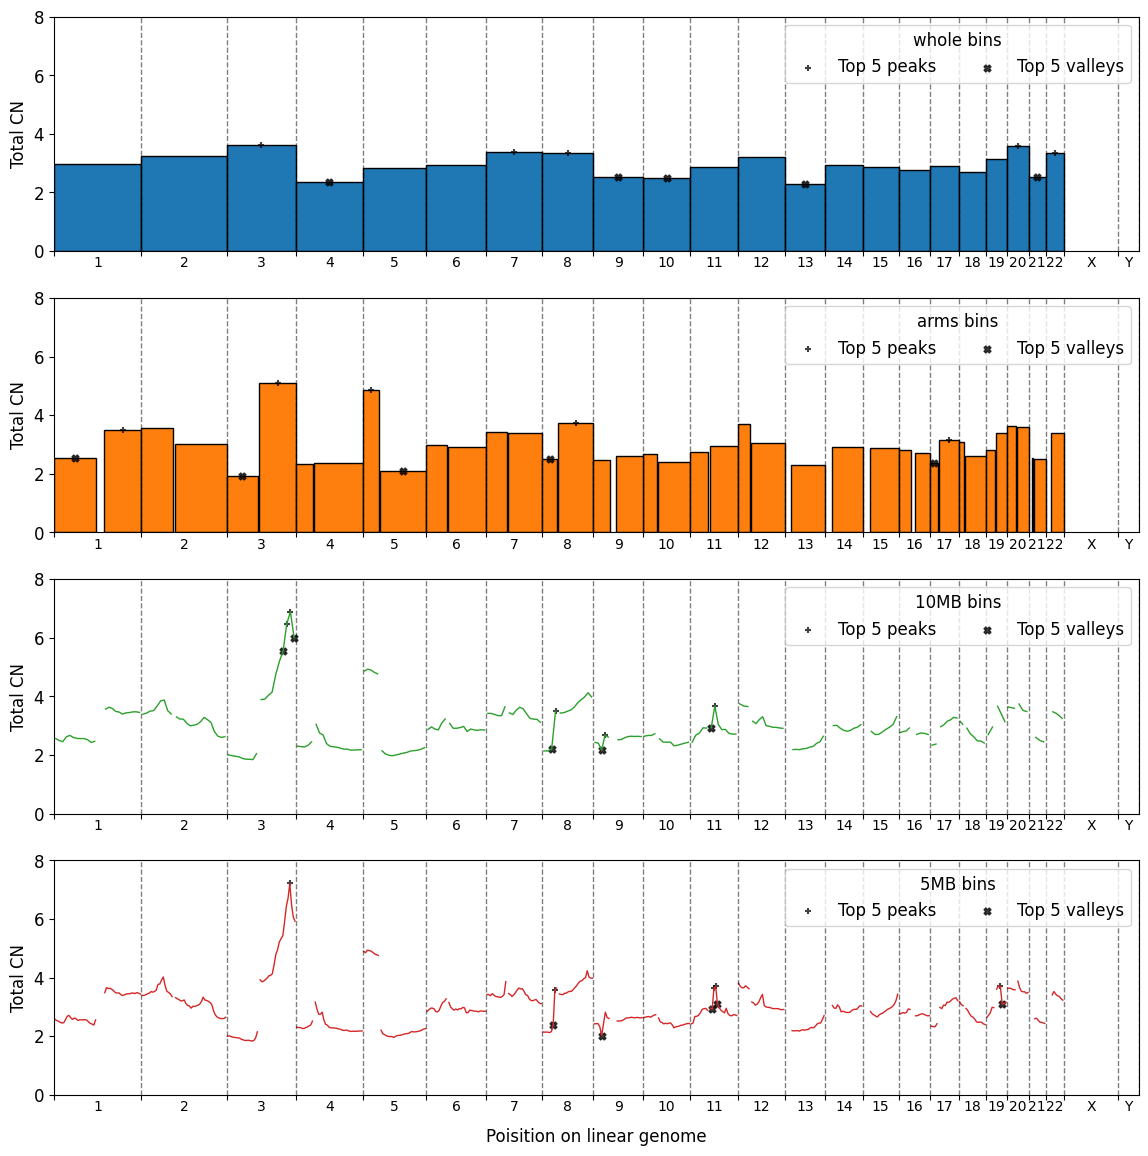

In [ ]:
fig, axs = plt.subplots(len(cns_dfs), 1, figsize=(14, 14))

for i, (grouping, cns_df) in enumerate(cns_dfs.items()):
	sel_df = cns.select_cns_by_type(cns_df, samples_df, cancer_type) if cancer_type != "all" else cns_df
	group_df = cns.group_samples(cns.only_aut(cns.add_total_cn(sel_df)))
	group_df["sample_id"] = f"mean {cancer_type} CN"
	group_df = cns.add_cum_mid(group_df)
	if grouping == "whole":
		group_by = "sample"
	elif grouping == "arms":
		group_by = "chrom"
	else:
		group_by = "cons"
	group_df["score"] = cns.calc_angles(group_df, "total_cn", group_by=group_by)

	if grouping == "whole" or grouping == "arms":
		cns.plot_bars(axs[i], group_df, cn_column="total_cn", color=color_map[i])
	else:
		cns.plot_lines(axs[i], group_df, cn_column="total_cn", color=color_map[i])
	cns.plot_x_lines(axs[i])
	cns.plot_x_ticks(axs[i])

	group_df = group_df.sort_values(by="score")
	axs[i].scatter(group_df["cum_mid"].head(val_count), group_df["total_cn"].head(val_count), color="k", alpha=0.75, s=25, label=f"Top {val_count} peaks", marker="+")
	axs[i].scatter(group_df["cum_mid"].tail(val_count), group_df["total_cn"].tail(val_count), color="k", alpha=0.75, s=25, label=f"Top {val_count} valleys", marker="X")
	axs[i].set_ylim(0, 8)
	axs[i].set_ylabel("Total CN")
	axs[i].legend(title=f"{grouping} bins", loc="upper right", ncol=3)

axs[-1].set_xlabel("Poisition on linear genome")

cdu.save_cns_fig(f"peaks_valleys_{cancer_type}")

In [71]:
score_means = []

for i, (grouping, cns_df) in enumerate(cns_dfs.items()):
	print(grouping)
	sel_df = cns.select_cns_by_type(cns_df, samples_df, cancer_type) if cancer_type != "all" else cns_df
	sel_df = cns.group_samples(cns.only_aut(cns.add_total_cn(sel_df)))
	sel_df["sample_id"] = f"mean {cancer_type} CN"
	sel_df["score"] = cns.calc_angles(sel_df, "total_cn")	
	score_means.append(cns.mean_value_per_seg(sel_df, ensembl, "score"))

mean_dfs = {}
mean_df = score_means[0].copy()
for vals in score_means[1:]:
	mean_df["score"] += vals["score"]
mean_df["score"] /= len(score_means)
mean_df["total_cn"] = cns.mean_value_per_seg(sel_df, ensembl, "total_cn")["total_cn"]
mean_df = pd.merge(mean_df, cosmic_df, how="left")

print(mean_df[~mean_df["gene"].isna()].sort_values(by="score", ascending=True).head(10))
cns.save_cns(mean_df, cdu.pjoin(cdu.out_path, f"gene_scores_{cancer_type}.tsv"))

whole
arms
10MB
5MB
      chrom      start        end             name     score  total_cn  \
14166  chr3  181429713  181432221  ENSG00000181449 -2.730332  7.213184   
14152  chr3  178865901  178957881  ENSG00000121879 -2.730332  7.213184   
14210  chr3  185764096  185828107  ENSG00000244405 -2.549687  6.490606   
14230  chr3  187439164  187463515  ENSG00000113916 -2.549687  6.490606   
14207  chr3  185361526  185542844  ENSG00000073792 -2.549687  6.490606   
14203  chr3  185000728  185206885  ENSG00000073803 -2.549687  6.490606   
14219  chr3  186500993  186507689  ENSG00000156976 -2.549687  6.490606   
14149  chr3  176737142  176915261  ENSG00000177565 -2.501914  6.710870   
14117  chr3  168801286  169381406  ENSG00000085276 -2.430254  6.424231   
14231  chr3  187871071  188608460  ENSG00000145012 -2.250578  6.178193   

          gene  
14166     SOX2  
14152   PIK3CA  
14210     ETV5  
14230     BCL6  
14207  IGF2BP2  
14203  MAP3K13  
14219   EIF4A2  
14149  TBL1XR1  
14117    MEC